In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
x = np.random.randn(1,200)

y = 2 * x**2 + 3*np.random.random((1,200))

In [3]:
x.shape, y.shape

((1, 200), (1, 200))

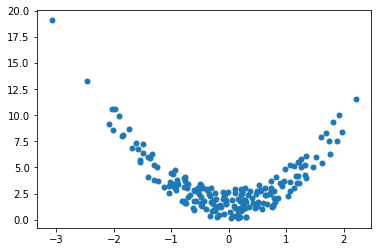

In [4]:
plt.scatter(x, y, marker='o',   s=25)

In [5]:
def purity_test(Y):   
    unique_classes = np.unique(Y)
    return len(unique_classes) == 1

print(purity_test([1,0,1,0]))
print(purity_test([1,1,1,1]))

False
True


In [6]:
def classify_data_using_mode(Y):
    return np.mean(Y)

print(classify_data_using_mode([1,0,1,0]))
print(classify_data_using_mode([1,1,1,1]))

0.5
1.0


In [7]:
def get_potential_splits(data):
    potential_splits = {}
    n_columns, _ = data.shape
    for column_index in range(n_columns):        
        potential_splits[column_index] = []
        values = data[column_index,:]
        unique_values = np.unique(values)
        for index in range(len(unique_values)):
            if index != 0:
                current_value = unique_values[index]
                previous_value = unique_values[index - 1]
                potential_split = (current_value + previous_value) / 2
                potential_splits[column_index].append(potential_split)
    return potential_splits

In [8]:
potential_splits = get_potential_splits(x)

In [9]:
def split_data(x, y,split_column, split_value):
    split_column_values = x[split_column,:]

    x_below = x[:,np.where(split_column_values <= split_value)]
    y_below = y[:,np.where(split_column_values <= split_value)]
    x_above = x[:,np.where(split_column_values > split_value)]
    y_above = y[:,np.where(split_column_values > split_value)]    
    return x_above.squeeze(axis=1),y_above.squeeze(axis=1), x_below.squeeze(axis=1),y_below.squeeze(axis=1)

In [10]:
data_above,y_above, data_below,y_below = split_data(x,y, 0, 0.5)

print(x.shape,data_below.shape,y_below.shape,data_above.shape,y_above.shape)

(1, 200) (1, 142) (1, 142) (1, 58) (1, 58)


In [11]:
def Calculate_SSE(y_below,y_above):     
    return np.var(y_below) + np.var(y_above)

Calculate_SSE(y_below,y_above)

12.714331515900879

In [12]:
def determine_best_split(x,y, potential_splits):
    
    overall_entropy = 9999
    for column_index in potential_splits:
        for value in potential_splits[column_index]:
            data_above, y_above, data_below, y_below = split_data(x,y, 
                                                                  split_column=column_index, 
                                                                  split_value=value)
            
            current_overall_entropy = Calculate_SSE(y_above, y_below)

            if current_overall_entropy <= overall_entropy:
                overall_entropy = current_overall_entropy
                best_split_column = column_index
                best_split_value = value
                
    return best_split_column, best_split_value

In [13]:
determine_best_split(x,y, potential_splits)

(0, -2.7707117953097455)

In [14]:
def decision_tree_algorithm(x, y, depth=0, min_samples=2, max_depth=5):    
    
    
    # base cases
    if (purity_test(y)) or (y.shape[1] < min_samples) or (depth == max_depth):
        classification = classify_data_using_mode(y)

        return "{}".format(round(classification,2))
    
    # recursive part
    else:    
        depth += 1

        # helper functions 
        potential_splits = get_potential_splits(x)
        split_column, split_value = determine_best_split(x, y, potential_splits)
        data_above,y_above, data_below,y_below  = split_data(x, y, split_column, split_value)
        
        # instantiate sub-tree
        question = "{} <= {}".format(split_column, split_value)
        sub_tree = {question: {}}
        # find answers (recursion)
        yes_answer = decision_tree_algorithm(data_below, y_below, depth, min_samples, max_depth)
        no_answer = decision_tree_algorithm(data_above, y_above, depth, min_samples, max_depth)
        
        # If the answers are the same, then there is no point in asking the qestion.
        # This could happen when the data is classified even though it is not pure
        # yet (min_samples or max_depth base cases).
        if yes_answer == no_answer:
            sub_tree = yes_answer
        else:
            if type(yes_answer)==dict:
                sub_tree[question]["yes"] = yes_answer
            else:
                sub_tree[question]["yes"] = {"Branch prediction {}".format(yes_answer):{}}
            if type(no_answer)==dict:
                sub_tree[question]["no"] = no_answer
            else:
                sub_tree[question]["no"] = {"Branch prediction {}".format(no_answer):{}}
        return sub_tree

In [15]:
import json

tree = decision_tree_algorithm(x,y, max_depth=4)

In [16]:
import pydot

menu = tree

def draw(parent_name, child_name,depth,color='blue'):
    edge = pydot.Edge("{}".format(parent_name), 
                      "{}".format(child_name),
                      color=color)
    graph.add_edge(edge)

def visit(node,depth, parent=None):
    for k,v in node.items():
        if isinstance(v, dict):
            # We start with the root node whose parent is None
            # we don't want to graph the None node
            if parent:
                if 'yes' in v.keys():   
                    draw(parent, list(v['yes'].keys())[0] ,depth,'green')
                    visit(v['yes'], depth+1, list(v['yes'].keys())[0])
                elif 'no' in v.keys():
                    draw(parent, list(v['no'].keys())[0],depth,'red')
                    visit(v["no"], depth+1,list(v['no'].keys())[0])
                elif k =="yes":
                    draw(parent, list(v.keys())[0],depth,'green')
                    visit(v[list(v.keys())[0]],depth, list(v.keys())[0])
                elif k =="no":
                    draw(parent, list(v.keys())[0],depth,'red')
                    visit(v[list(v.keys())[0]],depth, list(v.keys())[0])
                else:
                    draw(parent, k, depth)
                    visit(v, depth+1,k)
            else:
                visit(v,depth+1,k)              
                    
        else:
            draw(parent, k, depth)
            # drawing the label using a distinct name
            draw(k, k+'_'+v, depth)

graph = pydot.Dot(graph_type='graph')
visit(menu,0)

In [17]:
graph.write_png('example1_graph.png')

In [18]:
menu = tree

def tree_to_python_if_else(node,depth, parent=None):
    output = ""
    for k,v in node.items():
        if isinstance(v, dict):            
            if 'Branch prediction' in k:
                output+="{}output= {}\n".format("  "*depth,k.replace("Branch prediction","").strip())
            elif 'yes' in v:
                output+= "{}if (var_{}):\n".format("  "*depth, k)
                output+=tree_to_python_if_else(v["yes"],depth+1,k)  
                output+= "{}else:\n".format("  "*depth)
                output+=tree_to_python_if_else(v["no"],depth+1,k)                  
        else:
            print("\nnot dict:",k,v)
    return output

tree_python_code = tree_to_python_if_else(menu,0)

In [19]:
print(tree_python_code)

if (var_0 <= -2.7707117953097455):
  output= 19.1
else:
  if (var_0 <= -2.2696206918517623):
    output= 13.29
  else:
    if (var_0 <= -1.7150011590526928):
      if (var_0 <= -1.8842506636831748):
        output= 9.76
      else:
        output= 8.27
    else:
      if (var_0 <= 2.10006302867911):
        output= 2.98
      else:
        output= 11.58



In [20]:
def predict(tree, data):    
    for i in range(len(data)):
        exec("var_{} = {}".format(i, data[i]), locals())
    exec(tree, locals()) 
    return locals()['output']

In [21]:
print("data point is :",x[:,0])
print("predicted class:",predict(tree_python_code,x[:,0]))

data point is : [0.22306988]
predicted class: 2.98


In [22]:
y_pred = [predict(tree_python_code, x[:,i]) for i in range(x.shape[1])]

In [23]:
np.mean((np.abs(np.array(y_pred)-y)))

1.3792311272584277

In [24]:
X_test = np.arange(-3.0, 3.0, 0.01)[:, np.newaxis]
X_test = X_test.reshape(1,-1)

In [25]:
y_test_pred = [predict(tree_python_code, X_test[:,i]) for i in range(X_test.shape[1])]

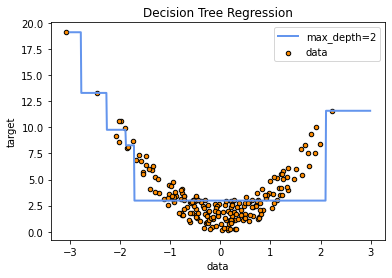

In [26]:
# Plot the results
plt.figure()
plt.scatter(x, y.reshape(1,-1), s=20, edgecolor="black",
            c="darkorange", label="data")
plt.plot(X_test.reshape(-1), np.array(y_test_pred).reshape(-1), color="cornflowerblue",
         label="max_depth=2", linewidth=2)
plt.xlabel("data")
plt.ylabel("target")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()